# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import DateOffset, BDay
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [2]:
url = 'https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv'

### Step 3. Assign it to a variable apple and apply a head()

In [3]:
apple = pd.read_csv(url, sep=',')
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 4.  Check out the type of the columns

In [4]:
apple.info()

<class 'pandas.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       8465 non-null   str    
 1   Open       8465 non-null   float64
 2   High       8465 non-null   float64
 3   Low        8465 non-null   float64
 4   Close      8465 non-null   float64
 5   Volume     8465 non-null   int64  
 6   Adj Close  8465 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 463.1 KB


### Step 5. Transform the Date column as a datetime type and check the info()

In [5]:
apple['Date'] = pd.to_datetime(apple['Date'])
apple.info()

<class 'pandas.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8465 non-null   datetime64[us]
 1   Open       8465 non-null   float64       
 2   High       8465 non-null   float64       
 3   Low        8465 non-null   float64       
 4   Close      8465 non-null   float64       
 5   Volume     8465 non-null   int64         
 6   Adj Close  8465 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 463.1 KB


### Step 6.  Set the date as the index

In [6]:
apple = apple.set_index('Date')

### Step 7.  Is there any duplicate dates?

In [7]:
# La fecha es el índice
apple.index.duplicated().sum()

np.int64(0)

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [8]:
apple = apple.sort_index()
apple

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41
...,...,...,...,...,...,...
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03


### Step 9. Get the last business day of each month

In [ ]:
# Buscamos los diferentes meses que hay
meses = apple.index.to_period('M').unique()
ult_labo = pd.Series() # Serie para guardar los días

for m in meses:
    ultimo = m.to_timestamp('M')  # último día natural del mes
    if ultimo.weekday() >= 5:     # 5 = sábado, 6 = domingo
        ultimo = ultimo - pd.offsets.BDay(1) # Recuperamos laborable anterior solo si es fin de semana
    ult_labo[m] = ultimo

ult_labo

1980-12   1980-12-31
1981-01   1981-01-30
1981-02   1981-02-27
1981-03   1981-03-31
1981-04   1981-04-30
             ...    
2014-03   2014-03-31
2014-04   2014-04-30
2014-05   2014-05-30
2014-06   2014-06-30
2014-07   2014-07-31
Freq: M, Length: 404, dtype: datetime64[us]

### Step 10.  What is the difference in days between the first day and the oldest

In [10]:
# Calculamos diferencia y pasamos a días
(apple.index.max() - apple.index.min()).days

12261

### Step 11.  How many months in the data we have?

In [11]:
# Tenemos en cuenta diferentes año-mes que tenemos en los índices
apple.index.to_period('M').unique()

PeriodIndex(['1980-12', '1981-01', '1981-02', '1981-03', '1981-04', '1981-05',
             '1981-06', '1981-07', '1981-08', '1981-09',
             ...
             '2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03',
             '2014-04', '2014-05', '2014-06', '2014-07'],
            dtype='period[M]', name='Date', length=404)

In [12]:
# Contamos cuántos valores hay
apple.index.to_period('M').nunique()

404

### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

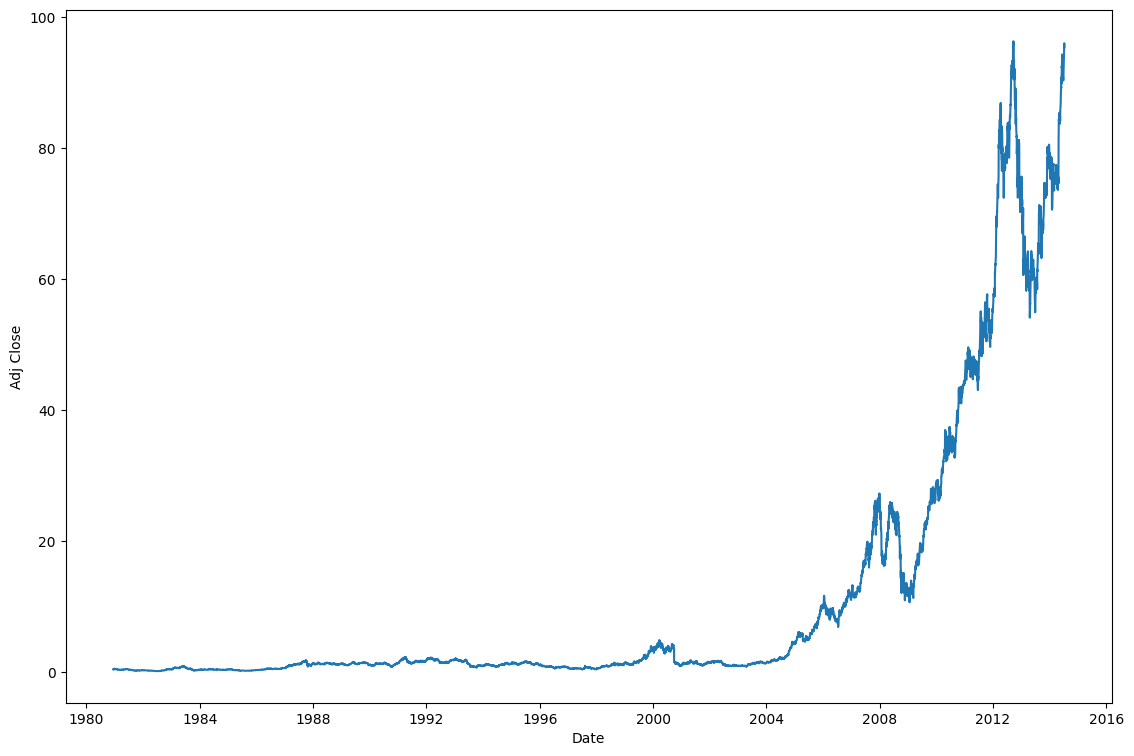

In [13]:
plt.figure(figsize=(13.5,9))
sns.lineplot(data=apple,
             x=apple.index,
             y='Adj Close');